In [203]:
import pandas as pd
import numpy as np
import re
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import chi2_contingency

__datapath__ = '../data/lab03/eda_task_data'

pd.set_option("display.max_columns", None)

In [204]:
columns: list[str]
with open(f'{__datapath__}/data_description.txt') as f:
  columns = ['Id', *re.findall(r'(?![story])\w+(?=:)', f.read()), 'SalePrice']

df = pd\
  .read_csv(f'{__datapath__}/train.csv', names=columns, index_col=False)\
  .drop(columns=['Id'])

num_cols = df.select_dtypes(include='number').columns

df.info()
df.head()

df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'Bedroom', 'Kitchen', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF',

In [205]:
for col in df.select_dtypes(exclude='number').columns:
  print(df[col].value_counts(), end='\n\n')

for col in df.select_dtypes(include='number').columns:
  print(df[col].value_counts(), end='\n\n')

# useless fields:
# - Utilities
# - Condition2
# - RoofMatl
# - Street
# - PoolQC
# - MiscFeature
# - Fence
# - Alley
# - 3SsnPorch

useless_fields = [
  'Utilities', 'Condition2', 'RoofMatl',
  'Street', 'PoolQC', 'MiscFeature',
  'Fence', '3SsnPorch'
]
df = df.drop(columns=useless_fields)


MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Ve

In [206]:
# no duplicate data

df.duplicated().value_counts()

False    1460
Name: count, dtype: int64

In [207]:
for col in df.select_dtypes(include='number').columns:
  if not df[col].isna().any():
    continue

  if abs(df[col].skew(skipna=True)) > 1:
    strategy = 'median'
  else:
    strategy = 'mean'

  imputer = SimpleImputer(strategy=strategy)
  df[[col]] = imputer.fit_transform(df[[col]])

for col in df.select_dtypes(exclude='number').columns:
  if not df[col].isna().any():
    continue

  imputer = SimpleImputer(strategy='most_frequent')
  df[[col]] = imputer.fit_transform(df[[col]])

print(df.isna().sum())

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Alley            0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 72, dtype: int64


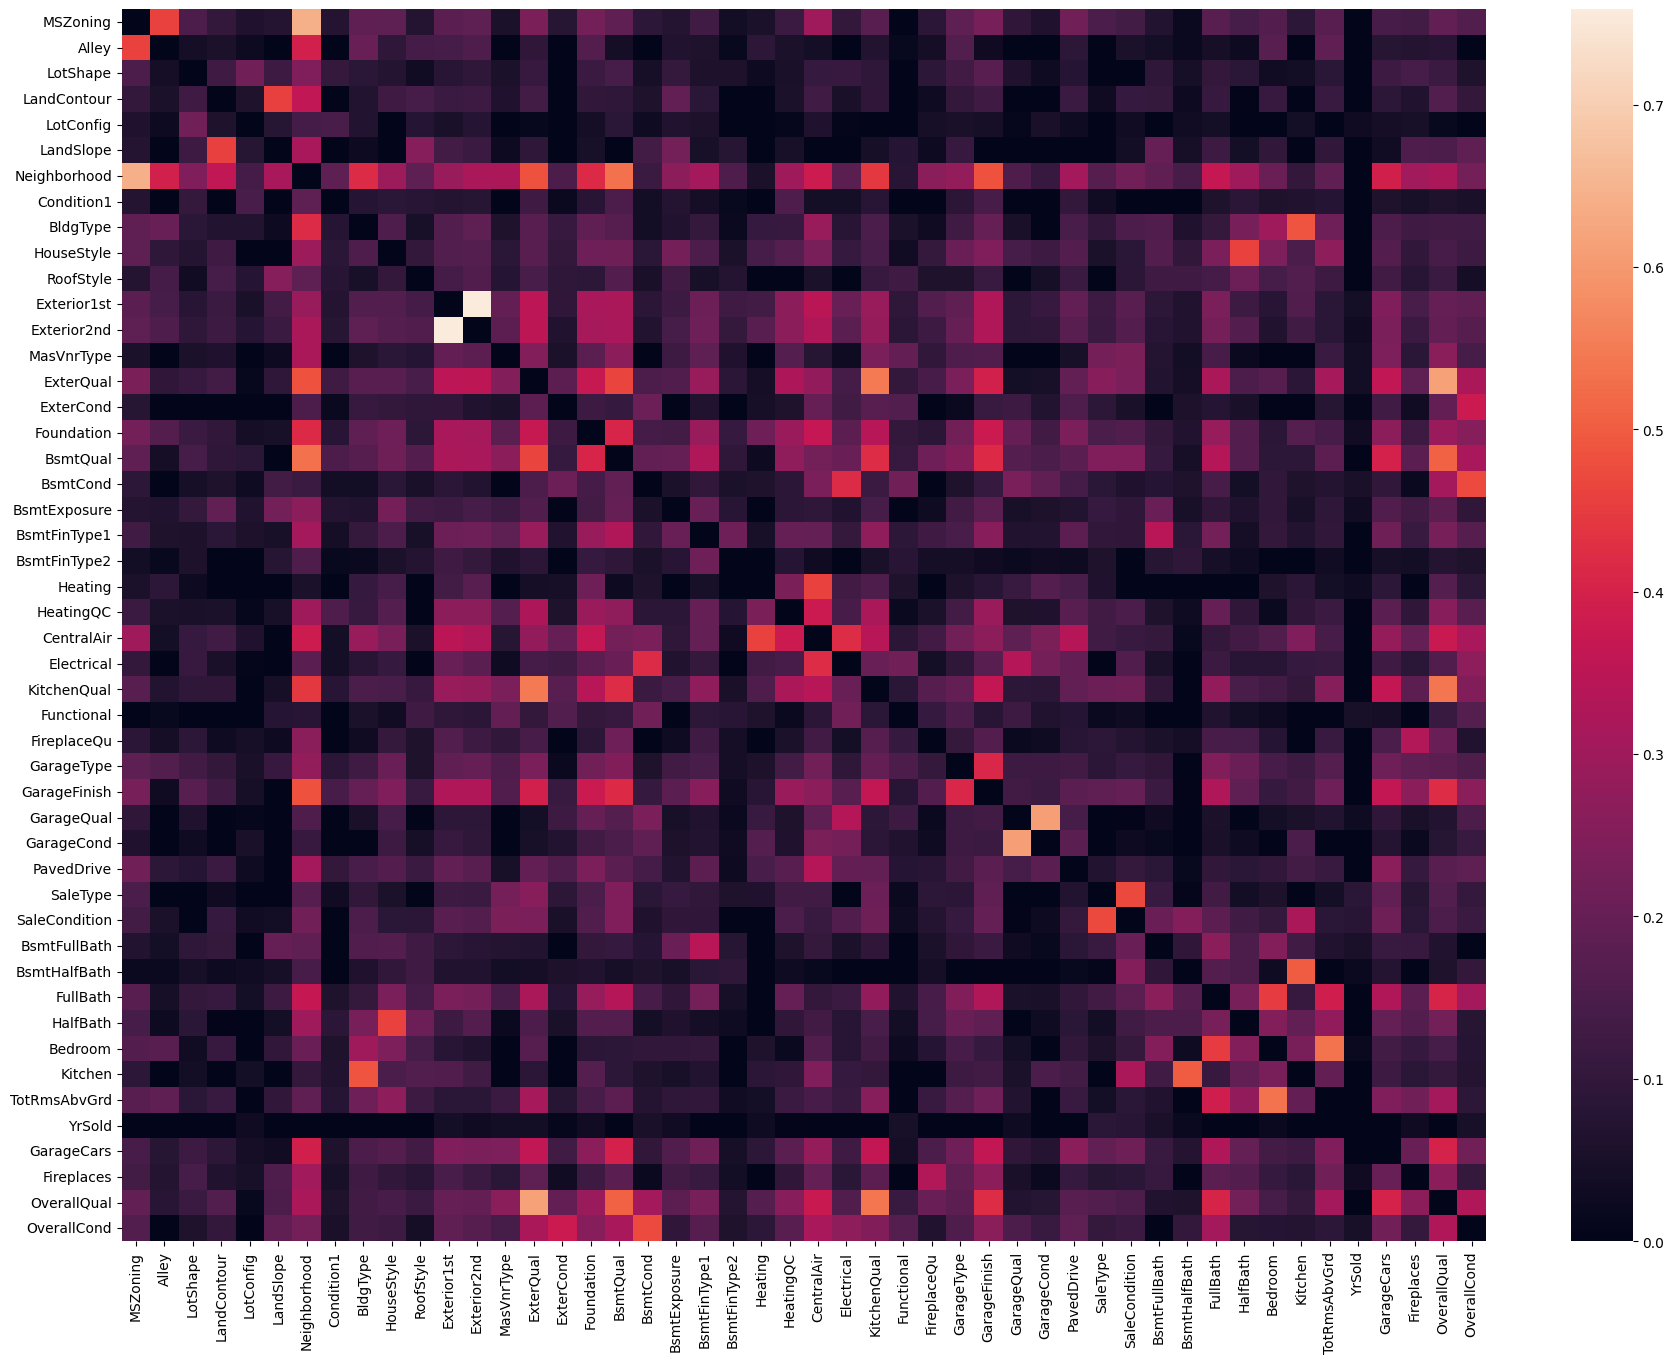

In [208]:
cat_df = df[[
  *df.select_dtypes(exclude='number').columns,
  'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'Bedroom', 'Kitchen', 'TotRmsAbvGrd', 'YrSold', 'GarageCars',
  'Fireplaces', 'OverallQual', 'OverallCond'
]]

chi2_df = pd.DataFrame(data=np.zeros([cat_df.shape[1]] * 2), columns=cat_df.columns, index=cat_df.columns)
for col1 in cat_df:
  for col2 in cat_df:
    if col1 == col2:
      continue
    contingency = np.array(pd.crosstab(cat_df[col1], cat_df[col2]))
    if all(s > 1 for s in contingency.shape):
      # http://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V#Bias_correction
      chi2, p, dof, expected = chi2_contingency(contingency)
      n = contingency.sum().sum()
      phi2 = chi2 / n
      r, k = contingency.shape
      phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
      rcorr = r - ((r-1)**2)/(n-1)
      kcorr = k - ((k-1)**2)/(n-1)
      cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
      chi2_df.loc[col1, col2] = cramers_v

plt.figure(figsize=(22, 16))
sns.heatmap(chi2_df)
plt.show()

In [209]:
# - TotRmsAbcGrd already gives the sum of all the amneties (kitchen, bedroom, half and full bath)
# - Central Air and Heating were also basically the same. Central Air is binary in nature and heating has more values to express. Dropping Central Air
# - Keeping OverallQual instead of OverallCond
# 

df = df.drop(columns=[
  'Kitchen', 'Bedroom', 'HalfBath', 'FullBath',
  'CentralAir',
  'BldgType',
  'Exterior1st',
  'SaleType',
  'OverallCond',
  'ExterQual', 'ExterCond',
  'BsmtQual', 'BsmtCond',
  'HeatingQC',
  'KitchenQual',
  'FireplaceQu',
  'GarageQual', 'GarageCond',
  'Alley'
])

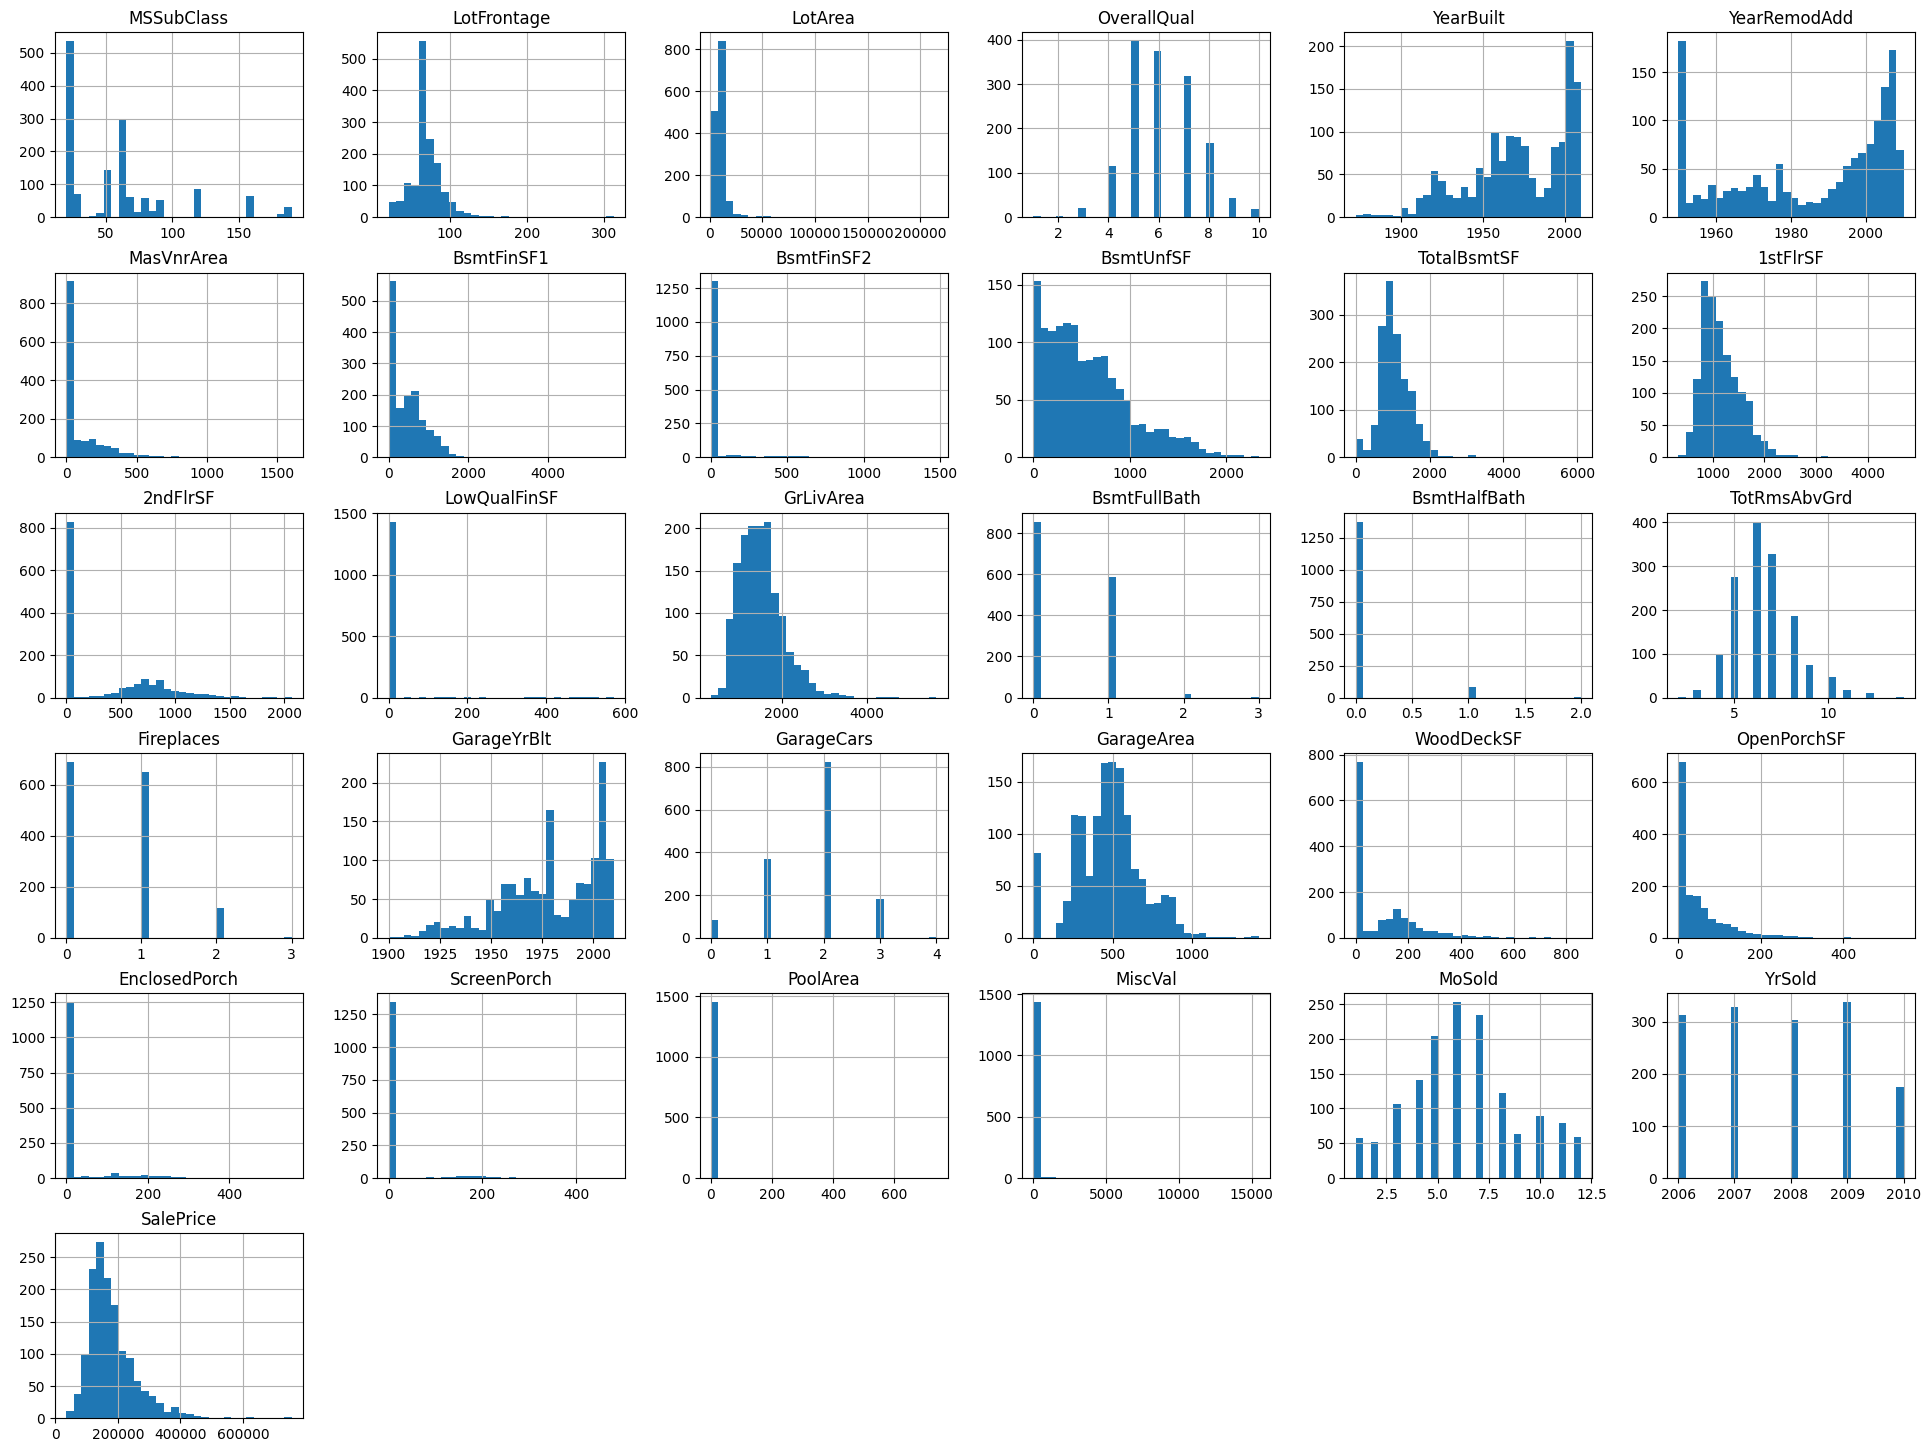

In [210]:
df.select_dtypes(include='number').hist(bins=30, figsize=(24,18))
plt.show()

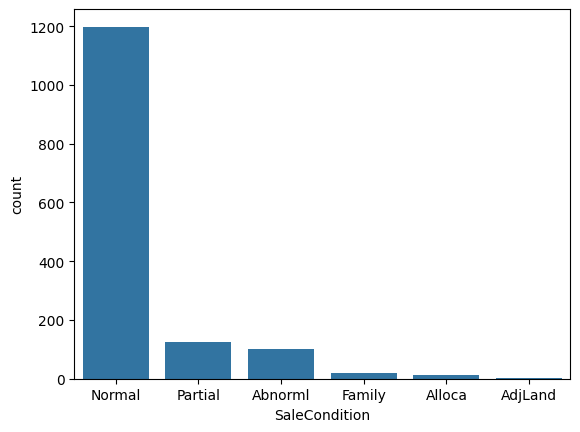

In [211]:

sns.countplot(data=df, x='SaleCondition', order=df['SaleCondition'].value_counts().index)
plt.show()

# not very balanced

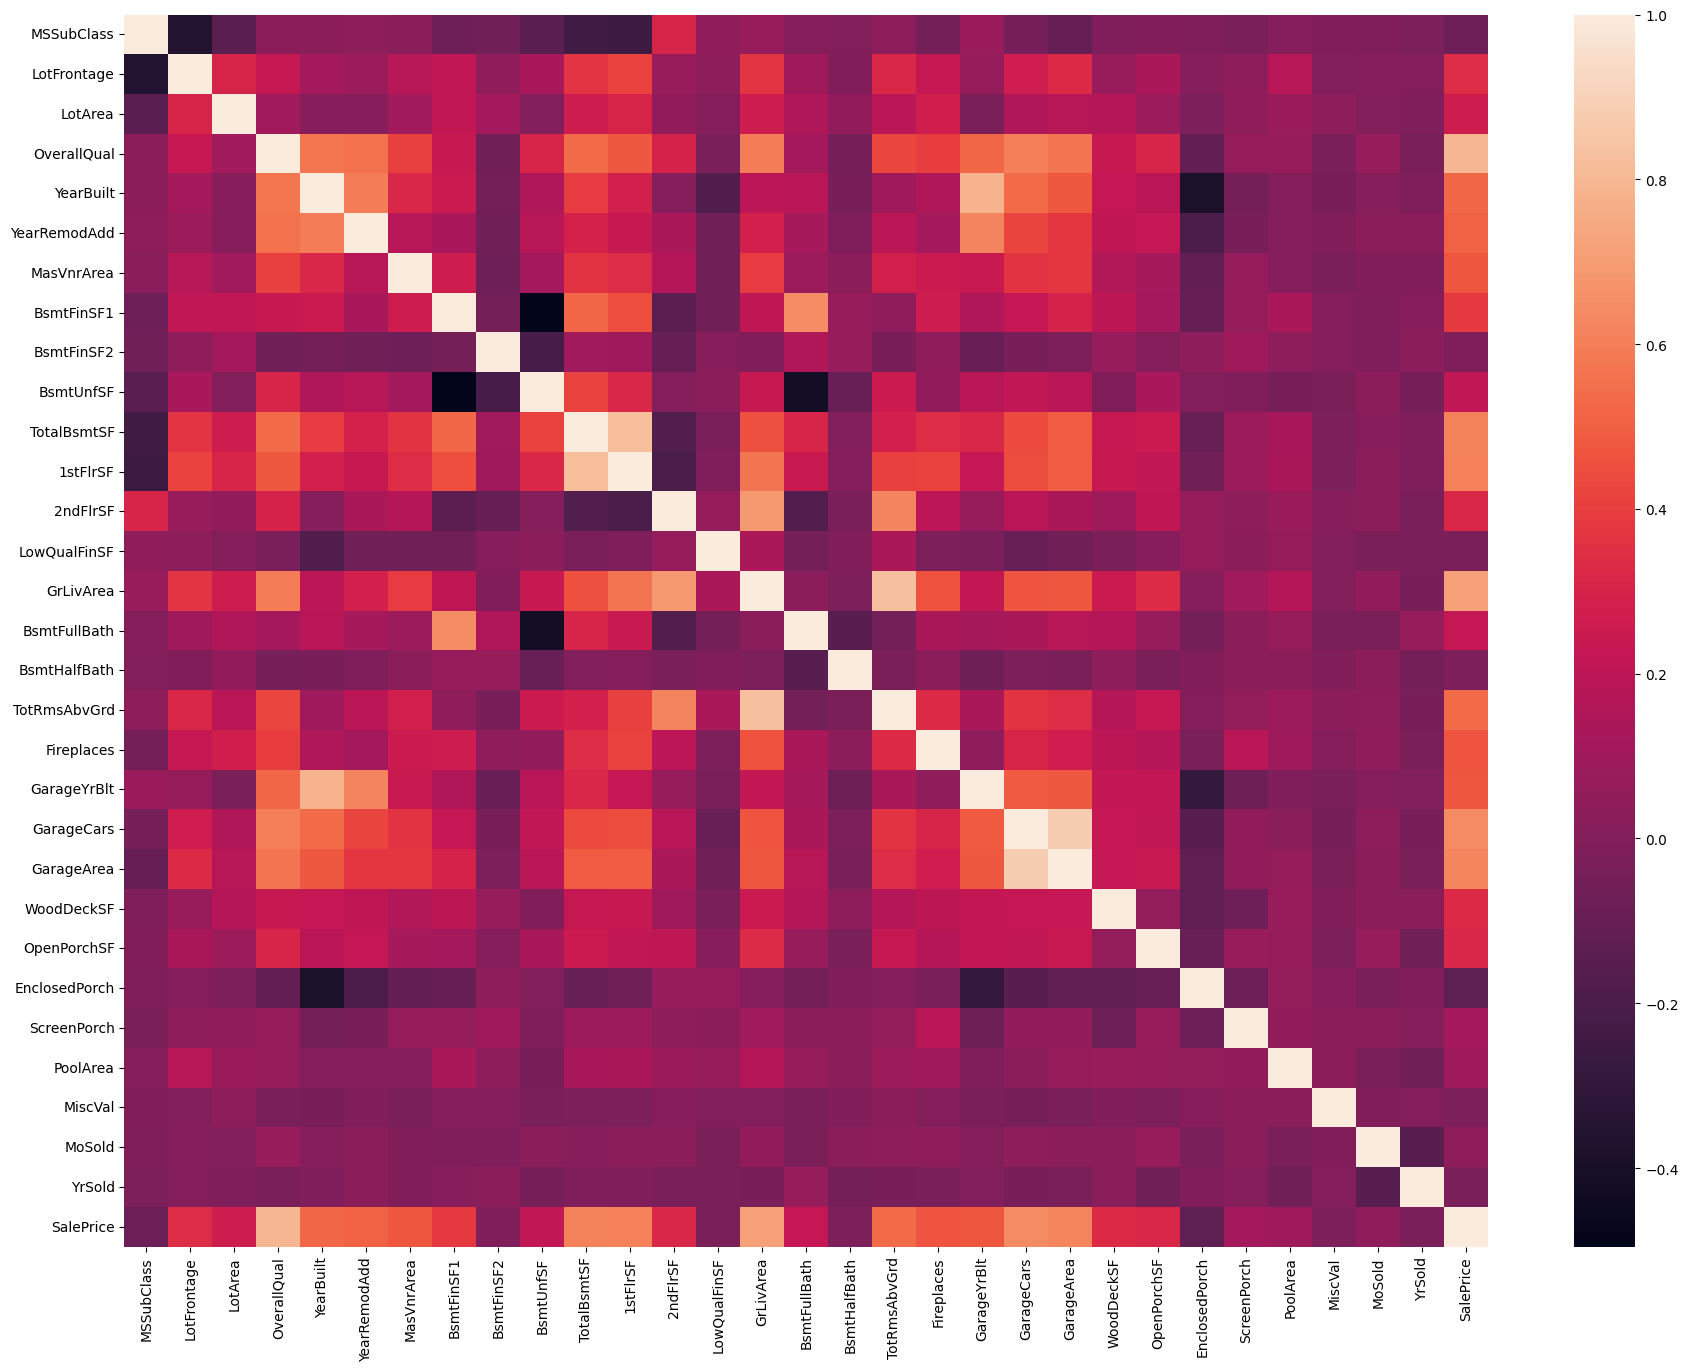

In [212]:
plt.figure(figsize=(22, 16))
sns.heatmap(data=df.select_dtypes(include='number').corr())
plt.show()

# all numeric columns were mostly highly correlated

In [213]:
# gonna perform PCA to see meaninful features

X = df.select_dtypes(include='number')

print(len(X.columns))

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=0.90, random_state=727)
pca_result = pca.fit_transform(X_scaled)
print(pca.n_components_)

# 19 components capture 90% of the information out of 30
# which means a lot of features are redundant and useless

# dropping highly related features should do the trick

pca_df = pd.DataFrame(
  data=pca.components_.T,
  columns=[f'PCA_{i}' for i in range(1, pca.n_components_+1)],
  index=X.select_dtypes(include='number').columns
)
low_contrib_features = pca_df.abs().max(axis=1)[pca_df.abs().max(axis=1) < 0.1].index
print(low_contrib_features)
# there seem to be no low contribution features from the PCA

31
19
Index([], dtype='object')


In [214]:
# trying random forest to see important numeric columns

X = df.select_dtypes(include='number')
y = df['SaleCondition']

rf = RandomForestClassifier(random_state=727)
rf.fit(X, y)

selector = SelectFromModel(rf, threshold="median", prefit=True)
selected_features = X.columns[selector.get_support()]
print(selected_features)

df = df.drop(columns=list(set(X.columns) - set(selected_features)))

Index(['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
       'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea',
       'GarageYrBlt', 'GarageArea', 'OpenPorchSF', 'MoSold', 'YrSold',
       'SalePrice'],
      dtype='object')


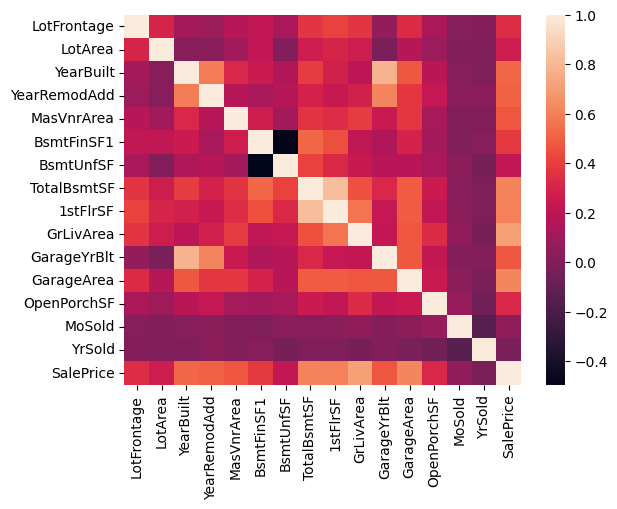

In [215]:
sns.heatmap(df.select_dtypes(include='number').corr())
plt.show()

In [216]:
df = df.drop(columns=['MoSold', 'YearRemodAdd', 'LotFrontage', 'BsmtUnfSF']) # dropping redundant numeric features

In [ ]:
# Predicting the SalePrice

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

preprocessor = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
  ]
)

pipeline = Pipeline([
  ("preprocessor", preprocessor),
  ("regressor", LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"RMSE: {rmse}\nR^2: {pipeline.score(X_test, y_test)}")

RMSE: 35037.28557016871
R^2: 0.8399531718774521
